# Laboratorio 8 — Etapa 3
## Incorporación del presupuesto y costo

**MM3014 Teoría de Probabilidades — MA UVG**

### Pedro Caso y Diego Calderón

---

## Contexto

Se introduce un límite económico. El coleccionista dispone de un presupuesto fijo y debe decidir si puede completar el álbum o no. Se simula la compra secuencial de sobres hasta agotar el dinero o hasta completar la colección.

## Parámetros de la simulación

- Álbum reducido: $N = 100$ estampas, $S = 7$ estampas por sobre
- Precio por sobre individual: Q9.50
- Presupuesto total: Q1000
- Número de simulaciones: $R = 10{,}000$
- Semilla: 2026

## Importaciones y parámetros

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# parámetros del problema
N           = 100  # estampas distintas en el álbum
S           = 7 # estampas por sobre
precio      = 9.50 # precio por sobre (Q)
presupuesto = 1_000.0 # presupuesto total (Q)
R           = 10_000 # número de simulaciones
SEMILLA     = 2026

rng = np.random.default_rng(SEMILLA)

print("Parámetros cargados:")
print(f"  N={N} estampas, S={S} por sobre")
print(f"  Precio: Q{precio} y Presupuesto: Q{presupuesto:.0f}")
print(f"  Simulaciones: R={R:,} con Semilla: {SEMILLA}")


Parámetros cargados:
  N=100 estampas, S=7 por sobre
  Precio: Q9.5 y Presupuesto: Q1000
  Simulaciones: R=10,000 con Semilla: 2026


## Procedimiento de simulación

Para cada simulación:
1. Inicializar la colección vacía (conjunto o arreglo booleano)
2. Inicializar el gasto acumulado en cero y el contador de sobres comprados en cero
3. Mientras el gasto acumulado más el precio de un sobre no supere el presupuesto **y** la colección no esté completa: comprar un sobre, actualizar la colección y el contador de repetidos, actualizar el gasto y el número de sobres
4. Al finalizar, registrar: si se completó el álbum (1) o no (0); número de sobres comprados; número de estampas distintas obtenidas (en caso de no completar)

In [7]:
# Arrays de resultados
completado       = np.zeros(R, dtype=bool)
sobres_comprados = np.zeros(R, dtype=int)
distintas_no_ok  = []    # estampas distintas en corridas NO exitosas

for i in range(R):
    coleccion = set()
    gasto     = 0.0
    n_sobres  = 0

    # Comprar sobres mientras quede presupuesto Y falten estampas
    while (gasto + precio <= presupuesto) and (len(coleccion) < N):
        estampas = rng.integers(0, N, size=S)   # S estampas con reposición
        coleccion.update(estampas)
        gasto    += precio
        n_sobres += 1

    completado[i] = len(coleccion) == N
    sobres_comprados[i] = n_sobres
    
    if not completado[i]:
        distintas_no_ok.append(len(coleccion))

distintas_no_ok = np.array(distintas_no_ok)
print(f"Simulación completada: {R:,} corridas")
print(f"Exitosas: {completado.sum():,}")
print(f"No exitosas: {(~completado).sum():,}")

Simulación completada: 10,000 corridas
Exitosas: 9,382
No exitosas: 618


## Resultados a calcular

Con los datos de las 10,000 simulaciones, calcular:
- Probabilidad de completar el álbum con el presupuesto de Q1000
- Número esperado de sobres comprados (incluyendo las simulaciones que no completaron)
- Número esperado de estampas distintas obtenidas cuando se acaba el presupuesto (solo para los casos no exitosos)

In [9]:
prob_completar = completado.mean()
e_sobres = sobres_comprados.mean()
e_distintas = distintas_no_ok.mean() if len(distintas_no_ok) > 0 else float('nan')

print(f"  P(completar álbum con Q{presupuesto:.0f}) : {prob_completar:.4f}  ({prob_completar*100:.2f} %)")
print(f"  E[sobres comprados]           : {e_sobres:.2f}")
print(f"  E[distintas | no exitoso]     : {e_distintas:.2f}")


  P(completar álbum con Q1000) : 0.9382  (93.82 %)
  E[sobres comprados]           : 73.98
  E[distintas | no exitoso]     : 98.97


## Visualización

Elaborar un diagrama de barras que muestre la proporción de veces que se completó el álbum versus las que no se completó.

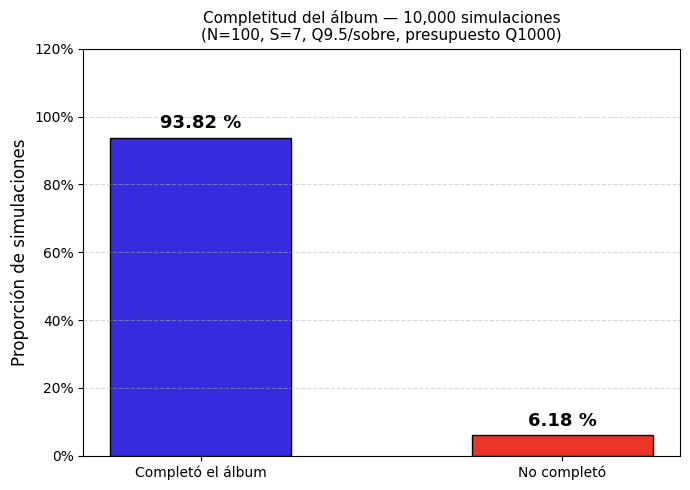

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

etiquetas = ["Completó el álbum", "No completó"]
proporciones = [prob_completar, 1 - prob_completar]
colores = ["#372BDE", "#EA3528"]

bars = ax.bar(etiquetas, proporciones, color=colores, edgecolor="black", width=0.5)

for bar, p in zip(bars, proporciones):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.015,
        f"{p*100:.2f} %",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.set_ylim(0, 1.2)
ax.set_ylabel("Proporción de simulaciones", fontsize=12)
ax.set_title(
    f"Completitud del álbum — {R:,} simulaciones\n"
    f"(N={N}, S={S}, Q{precio}/sobre, presupuesto Q{presupuesto:.0f})",
    fontsize=11
)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


---
## Preguntas de análisis

---

### Pregunta 1

¿Cuántos sobres se pueden comprar como máximo con Q1000? Calcular el número exacto. ¿Es suficiente esa cantidad de sobres, en teoría, para tener al menos $N$ estampas (ignorando repeticiones)? Comparar con el mínimo teórico de sobres sin repetidos.

**Análisis:**

> 

---
### Pregunta 2

Si en lugar de comprar sobres sueltos se compra una caja de 104 sobres (costo Q975), ¿cuál sería la probabilidad de completar el álbum? Simular esta situación (con las mismas 10,000 repeticiones, comprando exactamente los 104 sobres de la caja, no uno a uno hasta alcanzar el presupuesto). Comparar el resultado con la probabilidad obtenida comprando sobres sueltos con Q1000. ¿Conviene la caja?

> **Nota:** para la simulación con caja, simplemente comprar exactamente 104 sobres y verificar si al final se completó el álbum. No hay restricción de presupuesto más allá del costo fijo de la caja.

**Análisis:**

> 

---
### Pregunta 3

Analizar el caso intermedio: comprar una caja (104 sobres) y, si falta dinero para más sobres, no comprar ninguno adicional. ¿Cómo afecta al presupuesto no gastado? Proponer una estrategia de compra mixta (caja + algunos sueltos) que maximice la probabilidad de completar el álbum sin exceder Q1000.

**Análisis:**

> 